In [ ]:
import pandas as pd
from sklearn.preprocessing import MinMaxScaler
from sklearn.model_selection import train_test_split
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense
import numpy as np
import os
import cdsapi
import xarray as xr
import zipfile
from pathlib import Path
from concurrent.futures import ThreadPoolExecutor, as_completed
from keras.callbacks import EarlyStopping


In [42]:
# iterate through later
df = pd.read_csv(r"datasets\FIRMS\MODIS\fire_archive_M-C61_601999.csv")
df.head(5)

,latitude,longitude,brightness,scan,track,acq_date,acq_time,satellite,instrument,confidence,version,bright_t31,frp,daynight,type
0,-12.4005,141.7752,321.3,2.6,1.5,2019-10-01,26,Terra,MODIS,60,6.03,300.4,32.7,D,0
1,-12.4045,141.7985,319.1,2.5,1.5,2019-10-01,26,Terra,MODIS,52,6.03,300.1,25.3,D,0
2,-14.2813,143.5160,340.4,1.7,1.3,2019-10-01,26,Terra,MODIS,87,6.03,302.8,74.2,D,0
3,-12.4528,141.7104,321.8,2.6,1.5,2019-10-01,26,Terra,MODIS,0,6.03,300.4,42.1,D,0
4,-12.6828,142.0544,335.7,2.4,1.5,2019-10-01,26,Terra,MODIS,81,6.03,302.9,92.9,D,0


In [43]:
df['acq_time'] = df['acq_time'].astype(str).str.zfill(4)
df['datetime'] = pd.to_datetime(df['acq_date'] + ' ' + df['acq_time'], format='%Y-%m-%d %H%M')
df[['acq_date', 'acq_time']].head(5)

,acq_date,acq_time
0,2019-10-01,0026
1,2019-10-01,0026
2,2019-10-01,0026
3,2019-10-01,0026
4,2019-10-01,0026


In [44]:
df['date'] = pd.to_datetime(df['acq_date']).dt.date
df['lat'] = (df['latitude'] // 0.5) * 0.5
df['lon'] = (df['longitude'] // 0.5) * 0.5
df['hour'] = df['acq_time'].astype(str).str.zfill(4).str[:2].astype(int)
df.head(5)

,latitude,longitude,brightness,scan,track,acq_date,acq_time,satellite,instrument,confidence,version,bright_t31,frp,daynight,type,datetime,date,lat,lon,hour
0,-12.4005,141.7752,321.3,2.6,1.5,2019-10-01,0026,Terra,MODIS,60,6.03,300.4,32.7,D,0,2019-10-01 00:26:00,2019-10-01,-12.5,141.5,0
1,-12.4045,141.7985,319.1,2.5,1.5,2019-10-01,0026,Terra,MODIS,52,6.03,300.1,25.3,D,0,2019-10-01 00:26:00,2019-10-01,-12.5,141.5,0
2,-14.2813,143.5160,340.4,1.7,1.3,2019-10-01,0026,Terra,MODIS,87,6.03,302.8,74.2,D,0,2019-10-01 00:26:00,2019-10-01,-14.5,143.5,0
3,-12.4528,141.7104,321.8,2.6,1.5,2019-10-01,0026,Terra,MODIS,0,6.03,300.4,42.1,D,0,2019-10-01 00:26:00,2019-10-01,-12.5,141.5,0
4,-12.6828,142.0544,335.7,2.4,1.5,2019-10-01,0026,Terra,MODIS,81,6.03,302.9,92.9,D,0,2019-10-01 00:26:00,2019-10-01,-13.0,142.0,0


In [45]:
df_unique = df.drop_duplicates(subset=['lat', 'lon', 'acq_date'], keep=False)
df_unique = df_unique.reset_index()
print(len(df_unique))
df_unique.head(5)

5555


,index,latitude,longitude,brightness,scan,track,acq_date,acq_time,satellite,instrument,...,version,bright_t31,frp,daynight,type,datetime,date,lat,lon,hour
0,5,-12.0982,142.3159,322.0,2.4,1.5,2019-10-01,0026,Terra,MODIS,...,6.03,296.0,42.2,D,0,2019-10-01 00:26:00,2019-10-01,-12.5,142.0,0
1,31,-15.3763,145.2624,325.5,1.3,1.1,2019-10-01,0027,Terra,MODIS,...,6.03,299.5,25.5,D,0,2019-10-01 00:27:00,2019-10-01,-15.5,145.0,0
2,42,-19.0347,146.6097,310.9,1.0,1.0,2019-10-01,0027,Terra,MODIS,...,6.03,300.4,7.7,D,3,2019-10-01 00:27:00,2019-10-01,-19.5,146.5,0
3,85,-26.7312,145.7333,325.1,1.0,1.0,2019-10-01,0030,Terra,MODIS,...,6.03,310.8,8.7,D,0,2019-10-01 00:30:00,2019-10-01,-27.0,145.5,0
4,89,-30.9695,147.2585,331.6,1.1,1.1,2019-10-01,0031,Terra,MODIS,...,6.03,306.0,22.0,D,0,2019-10-01 00:31:00,2019-10-01,-31.0,147.0,0


In [46]:
grouped = df.groupby(['lat', 'lon'])['acq_date'].unique().reset_index()
grouped.head(5)

,lat,lon,acq_date
0,-44.0,146.5,"[2020-03-18, 2020-03-27]"
1,-43.5,146.5,"[2019-10-23, 2020-01-09, 2020-03-27, 2020-03-28]"
2,-43.5,147.5,[2020-04-09]
3,-43.0,145.0,[2020-03-11]
4,-43.0,146.0,"[2019-12-22, 2020-04-01, 2020-04-09]"


In [47]:
grouped

,lat,lon,acq_date
0,-44.0,146.5,"[2020-03-18, 2020-03-27]"
1,-43.5,146.5,"[2019-10-23, 2020-01-09, 2020-03-27, 2020-03-28]"
2,-43.5,147.5,[2020-04-09]
3,-43.0,145.0,[2020-03-11]
4,-43.0,146.0,"[2019-12-22, 2020-04-01, 2020-04-09]"
...,...,...,...
1731,-11.5,142.5,"[2019-12-02, 2019-12-06, 2019-12-07, 2019-12-0..."
1732,-11.0,142.0,"[2019-10-05, 2019-10-06, 2019-10-08, 2019-10-0..."
1733,-10.5,142.0,"[2019-11-15, 2020-01-27]"
1734,-10.0,142.0,[2020-01-03]


In [ ]:
c = cdsapi.Client()

def download_and_extract(lat, lon, date):
    year = str(date.year)
    month = f"{date.month:02d}"
    day = f"{date.day:02d}"

    area = [
        lat + 0.25, lon - 0.25,
        lat - 0.25, lon + 0.25
    ]

    output_filename = f"./datasets/era5/era5_fire_{year}{month}{day}_{lat:.2f}_{lon:.2f}.zip"
    extract_path = f"./datasets/era5/era5_fire_{year}{month}{day}_{lat:.2f}_{lon:.2f}/"

    if os.path.exists(extract_path):
        print(f"[SKIP] Already exists: {extract_path}")
        return

    print(f"[REQUEST] {date.date()} lat: {lat}, lon: {lon}")

    try:
        c.retrieve(
            'reanalysis-era5-single-levels',
            {
                "product_type": "reanalysis",
                "variable": [
                    "10m_u_component_of_wind",
                    "10m_v_component_of_wind",
                    "2m_dewpoint_temperature",
                    "2m_temperature",
                    "mean_sea_level_pressure",
                    "sea_surface_temperature",
                    "significant_height_of_combined_wind_waves_and_swell",
                    "surface_pressure",
                    "total_precipitation"
                ],
                "year": year,
                "month": month,
                "day": day,
                "time": [f"{x:02d}:00" for x in range(24)],
                "area": area,
                "data_format": "netcdf"
            },
            output_filename
        )

        with zipfile.ZipFile(output_filename, "r") as zip_ref:
            zip_ref.extractall(extract_path)

        print(f"[DONE] Extracted to {extract_path}")

    except Exception as e:
        print(f"[ERROR] Failed for {lat}, {lon}, {date.date()}: {e}")

# Build tasks
tasks = []
for idx, row in grouped.iterrows():
    lat = row['lat']
    lon = row['lon']
    dates = pd.to_datetime(row['acq_date'])

    for date in dates:
        tasks.append((lat, lon, date))

    if idx >= 100:
        break

# Run in parallel
MAX_WORKERS = 15  # Try tuning this to match your system
with ThreadPoolExecutor(max_workers=MAX_WORKERS) as executor:
    futures = [executor.submit(download_and_extract, lat, lon, date) for lat, lon, date in tasks]
 
    for future in as_completed(futures):
        future.result()  # Propagate exceptions if any


2025-04-14 20:40:59,425 INFO [2024-09-26T00:00:00] Watch our [Forum](https://forum.ecmwf.int/) for Announcements, news and other discussed topics.
2025-04-14 20:40:59,427 WARNING [2024-06-16T00:00:00] CDS API syntax is changed and some keys or parameter names may have also changed. To avoid requests failing, please use the "Show API request code" tool on the dataset Download Form to check you are using the correct syntax for your API request.


[SKIP] Already exists: ./datasets/era5/era5_fire_20200318_-44.00_146.50/
[SKIP] Already exists: ./datasets/era5/era5_fire_20200327_-44.00_146.50/
[SKIP] Already exists: ./datasets/era5/era5_fire_20191023_-43.50_146.50/
[SKIP] Already exists: ./datasets/era5/era5_fire_20200109_-43.50_146.50/
[SKIP] Already exists: ./datasets/era5/era5_fire_20200327_-43.50_146.50/
[SKIP] Already exists: ./datasets/era5/era5_fire_20200328_-43.50_146.50/
[SKIP] Already exists: ./datasets/era5/era5_fire_20200409_-43.50_147.50/
[SKIP] Already exists: ./datasets/era5/era5_fire_20200311_-43.00_145.00/
[SKIP] Already exists: ./datasets/era5/era5_fire_20191222_-43.00_146.00/
[SKIP] Already exists: ./datasets/era5/era5_fire_20200409_-43.00_146.00/
[SKIP] Already exists: ./datasets/era5/era5_fire_20191001_-43.00_146.50/
[SKIP] Already exists: ./datasets/era5/era5_fire_20200401_-43.00_146.00/
[SKIP] Already exists: ./datasets/era5/era5_fire_20191005_-43.00_146.50/
[SKIP] Already exists: ./datasets/era5/era5_fire_20

2025-04-14 20:41:01,297 INFO Request ID is 2542486a-da49-49c4-b646-1295840b3fcb
2025-04-14 20:41:01,315 INFO Request ID is 1ed17b47-8d0b-47ef-85ca-f247979d3656
2025-04-14 20:41:01,467 INFO Request ID is 85148c7e-02fd-4eaf-aa72-72aa6c926bab
2025-04-14 20:41:01,471 INFO Request ID is 5ba9c737-794e-4058-a765-4174b634ad72
2025-04-14 20:41:01,481 INFO Request ID is 6a5cf979-413d-46e0-993e-6fb469fe092c
2025-04-14 20:41:01,488 INFO Request ID is 3b6217e6-f2bd-4698-bb4c-9cc90c26485d
2025-04-14 20:41:01,602 INFO status has been updated to accepted
2025-04-14 20:41:01,650 INFO Request ID is 27bfb183-9241-485c-a243-35ef87bc3ec8
2025-04-14 20:41:01,677 INFO Request ID is 041359dc-6239-47d8-a75e-eebb1d53f83e
2025-04-14 20:41:01,692 INFO Request ID is efc22330-bd12-4171-95f5-280c45293257
2025-04-14 20:41:01,697 INFO Request ID is 3fd1de08-22df-4bcf-96f1-8f0d3d709bef
2025-04-14 20:41:01,701 INFO Request ID is efd8f140-f01a-4667-90bc-bf4445b2c0f5
2025-04-14 20:41:01,714 INFO Request ID is 7159a8f8-21b

810038ee841b09f702f5462c4fd97f1c.zip:   0%|          | 0.00/131k [00:00<?, ?B/s]

[DONE] Extracted to ./datasets/era5/era5_fire_20200311_-41.50_145.00/
[REQUEST] 2019-10-05 lat: -41.5, lon: 146.5


...

[DONE] Extracted to ./datasets/era5/era5_fire_20200317_-41.50_147.00/
[REQUEST] 2020-02-28 lat: -41.5, lon: 147.5


2025-04-14 20:55:21,078 INFO status has been updated to accepted
2025-04-14 20:55:22,010 INFO Request ID is 29723505-7b42-4cfa-a0ca-93451db65ce4
2025-04-14 20:55:22,610 INFO status has been updated to accepted
2025-04-14 20:55:58,079 INFO status has been updated to successful


7293abb364a90cebb85e0e64cca9cf2b.zip:   0%|          | 0.00/131k [00:00<?, ?B/s]

[DONE] Extracted to ./datasets/era5/era5_fire_20200324_-41.50_147.00/
[REQUEST] 2020-03-17 lat: -41.5, lon: 147.5


2025-04-14 20:56:03,476 INFO Request ID is e9bb45ef-fdb2-4cd5-a415-0fb2dc4181f6
2025-04-14 20:56:03,805 INFO status has been updated to accepted
Recovering from connection error [HTTPSConnectionPool(host='cds.climate.copernicus.eu', port=443): Max retries exceeded with url: /api/retrieve/v1/jobs/35c6355b-2823-4614-ae59-394893c191d5?log=True&request=True (Caused by NameResolutionError("<urllib3.connection.HTTPSConnection object at 0x00000227288AD4D0>: Failed to resolve 'cds.climate.copernicus.eu' ([Errno 11001] getaddrinfo failed)"))], attempt 1 of 500
Retrying in 120 seconds
Recovering from connection error [HTTPSConnectionPool(host='cds.climate.copernicus.eu', port=443): Max retries exceeded with url: /api/retrieve/v1/jobs/d1d6f21f-324a-4d6f-ac75-b371407686a4?log=True&request=True (Caused by NameResolutionError("<urllib3.connection.HTTPSConnection object at 0x000002272892E550>: Failed to resolve 'cds.climate.copernicus.eu' ([Errno 11001] getaddrinfo failed)"))], attempt 1 of 500
Retry

In [ ]:
all_weather = []  # list to store each df_weather
base_path = Path('./datasets/era5')

for dir_path in base_path.iterdir():
    if dir_path.is_dir():
        nc_path = dir_path / 'data_stream-oper_stepType-instant.nc'
        if nc_path.exists():
            try:
                # Load dataset
                ds = xr.open_dataset(nc_path, engine='netcdf4')
                
                # Convert Kelvin to Celsius
                ds['t2m'] = ds['t2m'] - 273.15
                ds['d2m'] = ds['d2m'] - 273.15

                # Compute relative humidity
                rh = 100 * (np.exp((17.625 * ds['d2m']) / (243.04 + ds['d2m'])) /
                            np.exp((17.625 * ds['t2m']) / (243.04 + ds['t2m'])))
                ds['humidity'] = rh

                # Compute wind speed
                wind_speed = (ds['u10'] ** 2 + ds['v10'] ** 2) ** 0.5
                ds['wind_speed'] = wind_speed

                # Convert to DataFrame
                df_weather = ds[['t2m', 'd2m', 'msl', 'sst', 'sp', 'humidity', 'wind_speed', 'valid_time']].to_dataframe().reset_index()
                df_weather['date'] = pd.to_datetime(df_weather['valid_time']).dt.date
                df_weather['hour'] = pd.to_datetime(df_weather['valid_time']).dt.hour
                df_weather = df_weather.rename(columns={'latitude': 'lat', 'longitude': 'lon'})

                # Add to list
                all_weather.append(df_weather)
            
            except Exception as e:
                print(f"Error processing {nc_path}: {e}")

# Concatenate all data
df_all_weather = pd.concat(all_weather, ignore_index=True)
len(df_all_weather)

34992

In [ ]:
# Mark fire cells
df['fire_label'] = 1
fire_cells = df[['lat', 'lon', 'date', 'fire_label', 'hour']].drop_duplicates()
fire_cells.head(5)

,lat,lon,date,fire_label,hour
0,-12.5,141.5,2019-10-01,1,0
2,-14.5,143.5,2019-10-01,1,0
4,-13.0,142.0,2019-10-01,1,0
5,-12.5,142.0,2019-10-01,1,0
7,-13.5,141.5,2019-10-01,1,0


In [ ]:

# Merge with weather
merged = df_all_weather.merge(fire_cells, on=['lat', 'lon', 'date', 'hour'], how='left')
merged['fire_label'] = merged['fire_label'].fillna(0)  # No fire = 0
len(merged)

34992

In [ ]:
merged[merged.fire_label == 1].head(5)

,valid_time,lat,lon,t2m,d2m,msl,sst,sp,humidity,wind_speed,number,expver,date,hour,fire_label
4,2019-10-01 00:00:00,-43.0,146.5,7.952057,3.471710,102803.1250,NaN,96971.2500,73.331123,3.984942,0,0001,2019-10-01,0,1.0
247,2019-10-02 03:00:00,-42.5,146.5,18.256378,3.350983,102138.6250,NaN,95552.3125,37.093548,2.930960,0,0001,2019-10-02,3,1.0
436,2019-10-03 00:00:00,-42.5,146.5,19.122101,6.776337,101758.1250,NaN,95212.7500,44.597858,2.132739,0,0001,2019-10-03,0,1.0
472,2019-10-03 04:00:00,-42.5,146.5,23.826813,4.591827,101302.9375,NaN,94824.5000,28.742235,4.294807,0,0001,2019-10-03,4,1.0
688,2019-10-03 04:00:00,-42.5,147.0,23.801422,6.605499,101346.6875,NaN,96354.5000,33.096394,5.006722,0,0001,2019-10-03,4,1.0


In [ ]:
features = merged[['t2m', 'd2m', 'msl', 'sp', 'humidity', 'wind_speed']]
labels = merged['fire_label']

In [ ]:
scaler = MinMaxScaler()
features_scaled = scaler.fit_transform(features)

labels = labels.reset_index(drop=True)

def seq(data, labels, window=7):
    x,y=[],[]
    for i in range(len(data)-window):
        x.append(data[i:i+window])
        y.append(labels[i+window])
    return np.array(x), np.array(y)

x, y = seq(features_scaled, labels)

In [ ]:
fire_indices = np.where(y == 1)[0]
no_fire_indices = np.where(y == 0)[0]
fire_upsampled_indices = np.random.choice(fire_indices, size=len(no_fire_indices), replace=True)

balanced_indices = np.concatenate([no_fire_indices, fire_upsampled_indices])
np.random.shuffle(balanced_indices)

x = x[balanced_indices]
y = y[balanced_indices]

In [ ]:
x_train, x_test, y_train, y_test = train_test_split(x, y, test_size=0.2, shuffle=False)

model = Sequential([
    LSTM(16, input_shape=(x.shape[1], x.shape[2])),
    Dense(1, activation='sigmoid')
])

model.compile(optimizer='adam', loss='binary_crossentropy', metrics=['accuracy'])
from sklearn.utils import class_weight

class_weights = class_weight.compute_class_weight(
    'balanced',
    classes=np.unique(y_train),
    y=y_train
)
class_weights = dict(enumerate(class_weights))


early_stop = EarlyStopping(monitor='val_loss', patience=3, restore_best_weights=True)

model.fit(x_train, y_train, epochs=10, batch_size=16,
          validation_data=(x_test, y_test),
          class_weight=class_weights, callbacks=[early_stop])

Epoch 1/10


c:\Users\olive\cs5131proj\venv\Lib\site-packages\keras\src\layers\rnn\rnn.py:200: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


3475/3475 ━━━━━━━━━━━━━━━━━━━━ 10s 3ms/step - accuracy: 0.6754 - loss: 0.6095 - val_accuracy: 0.7820 - val_loss: 0.4603
Epoch 2/10
3475/3475 ━━━━━━━━━━━━━━━━━━━━ 8s 2ms/step - accuracy: 0.7889 - loss: 0.4511 - val_accuracy: 0.8090 - val_loss: 0.4105
Epoch 3/10
3475/3475 ━━━━━━━━━━━━━━━━━━━━ 8s 2ms/step - accuracy: 0.8192 - loss: 0.4008 - val_accuracy: 0.8571 - val_loss: 0.3631
Epoch 4/10
3475/3475 ━━━━━━━━━━━━━━━━━━━━ 7s 2ms/step - accuracy: 0.8483 - loss: 0.3592 - val_accuracy: 0.8570 - val_loss: 0.3227
Epoch 5/10
3475/3475 ━━━━━━━━━━━━━━━━━━━━ 8s 2ms/step - accuracy: 0.8630 - loss: 0.3275 - val_accuracy: 0.8801 - val_loss: 0.2990
Epoch 6/10
3475/3475 ━━━━━━━━━━━━━━━━━━━━ 8s 2ms/step - accuracy: 0.8770 - loss: 0.3038 - val_accuracy: 0.8937 - val_loss: 0.2787
Epoch 7/10
3475/3475 ━━━━━━━━━━━━━━━━━━━━ 8s 2ms/step - accuracy: 0.8912 - loss: 0.2795 - val_accuracy: 0.9095 - val_loss: 0.2515
Epoch 8/10
3475/3475 ━━━━━━━━━━━━━━━━━━━━ 8s 2ms/step - accuracy: 0.9092 - loss: 0.2461 - val_accura

435/435 ━━━━━━━━━━━━━━━━━━━━ 1s 1ms/step
              precision    recall  f1-score   support

         0.0       0.95      0.91      0.93      6982
         1.0       0.91      0.95      0.93      6916

    accuracy                           0.93     13898
   macro avg       0.93      0.93      0.93     13898
weighted avg       0.93      0.93      0.93     13898



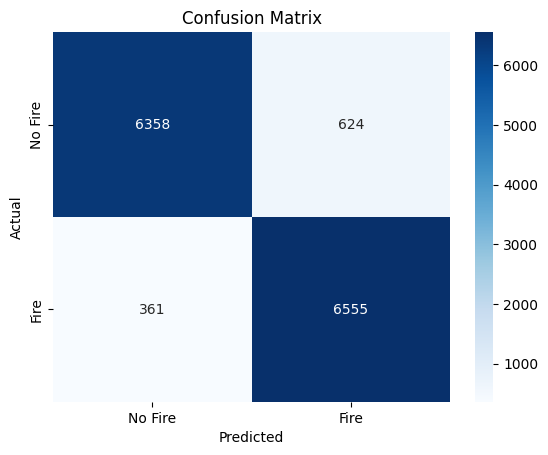

In [ ]:
from sklearn.metrics import classification_report, confusion_matrix
import matplotlib.pyplot as plt
import seaborn as sns

y_pred_prob = model.predict(x_test).flatten()
y_pred = (y_pred_prob > 0.5).astype(int)

print(classification_report(y_test, y_pred))

cm = confusion_matrix(y_test, y_pred)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=["No Fire", "Fire"], yticklabels=["No Fire", "Fire"])
plt.title("Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()
